![Getaround](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# What does a buffer between rentals cost?

Getaround's product manager wants to stop a late checkout from ruining the next rental, by
refusing to show a car in search results when the requested check-in is too close to the previous
checkout. Two things have to be decided: **how long the minimum delay should be**, and **whether
the feature applies to all cars or only to Connect cars.**

This notebook answers both from the 21 310 rentals in the delay file, and then builds the pricing
model that the `/predict` endpoint serves. The answer to the first question is smaller than the
question suggests:

> **The feature's entire target is 66 rentals out of 21 310** — the cases where the previous driver
> came back more than an hour after the next check-in was due, which is where the next rental's
> cancellation rate actually moves. Avoiding one of them costs between **10 and 25 blocked
> rentals**, and the ratio only gets worse as the threshold grows.
>
> **"Connect cars only" is the wrong scope, for the opposite of the expected reason.** Connect
> drivers are *less* late than mobile ones — 43% against 61%. Connect is where the problem shows up
> because Connect cars are chained back-to-back three times more often, not because their drivers
> behave worse. Restricting the feature there costs **18 blocked rentals per severe case avoided
> against 11** for all cars.

The second half of the notebook builds the price model and finds the same shape of answer: the
price is the car, not the equipment.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | The two files, and what one row is |
| 2 | What looks like cleaning here — and what each rule would cost |
| 3 | How often drivers are late, and whether it reaches the next driver |
| 4 | Threshold and scope: what each choice buys and what it costs |
| 5 | What the product manager should decide |
| 6 | The pricing model behind `/predict` |
| 7 | What ships |

Every claim below is the output of the cell above it.

## 1. The two files

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: the train/test split, every model fit and the grid searches
# in section 6 read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a contrast.
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


delay = pd.read_excel('data/get_around_delay_analysis.xlsx')
pricing = pd.read_csv('data/get_around_pricing_project.csv').drop(columns=['Unnamed: 0'])
print(f'delay file  : {delay.shape[0]:,} rentals x {delay.shape[1]} columns'.replace(',', ' '))
print(f'pricing file: {pricing.shape[0]:,} cars x {pricing.shape[1]} columns'.replace(',', ' '))
delay.head()

delay file  : 21 310 rentals x 7 columns
pricing file: 4 843 cars x 14 columns


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


### What one row is, and what the two files do not share

**One row of the delay file is one rental**: which car, whether the check-in was done through the
app or face to face, whether the rental ended or was cancelled, how many minutes late the car came
back, and — *only when there was one* — the rental that came immediately before it and the gap
between the two.

**One row of the pricing file is one car**, with its characteristics and the daily price its owner
charges. The cell below is the first thing to settle, because the product manager's first question
is about revenue.

In [2]:
print('delay columns  :', ', '.join(delay.columns))
print('pricing columns:', ', '.join(pricing.columns))
print()
print('columns the two files share:', set(delay.columns) & set(pricing.columns) or '{}')
print(f'car ids in the delay file  : {delay["car_id"].nunique():,} distinct cars'.replace(',', ' '))
print(f'car ids in the pricing file: none — the only identifier is the row number')
print()
print('missing values, delay file:')
print(delay.isna().sum().rename(lambda c: f'  {c}').to_string())
print(f'\nmissing values, pricing file: {pricing.isna().sum().sum()}')

delay columns  : rental_id, car_id, checkin_type, state, delay_at_checkout_in_minutes, previous_ended_rental_id, time_delta_with_previous_rental_in_minutes
pricing columns: model_key, mileage, engine_power, fuel, paint_color, car_type, private_parking_available, has_gps, has_air_conditioning, automatic_car, has_getaround_connect, has_speed_regulator, winter_tires, rental_price_per_day

columns the two files share: {}
car ids in the delay file  : 8 143 distinct cars
car ids in the pricing file: none — the only identifier is the row number

missing values, delay file:
rental_id                                         0
car_id                                            0
checkin_type                                      0
state                                             0
delay_at_checkout_in_minutes                   4964
previous_ended_rental_id                      19469
time_delta_with_previous_rental_in_minutes    19469

missing values, pricing file: 0


**The two files cannot be joined.** The pricing file has no car identifier, so no rental in the
delay file can be given a price. Every revenue figure in this notebook is therefore a **share of
rentals**, not a share of euros, and section 5.2 says what that assumption costs.

The missing values are not damage: `previous_ended_rental_id` and `time_delta` are missing for the
19 469 rentals that simply had no rental before them, and `delay_at_checkout_in_minutes` is missing
for **3 264 of the 3 265 cancelled** rentals — a rental that never happened has no checkout, and
the one exception is a single stray row.

## 2. What looks like cleaning here — and what it would cost

### 2.1 The delays are wild at both ends, and the tails are real records

In [3]:
ended = delay[delay['state'] == 'ended']
d = ended['delay_at_checkout_in_minutes'].dropna()

print(f'ended rentals            : {len(ended):,}'.replace(',', ' '))
print(f'with a checkout recorded : {len(d):,} ({len(d) / len(ended):.1%})'.replace(',', ' '))
print(f'\ndelay at checkout, in minutes:')
for q in (0.001, 0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999):
    print(f'  q{q:<6}: {d.quantile(q):>9,.0f}'.replace(',', ' '))
print(f'  min   : {d.min():>9,.0f}   max: {d.max():>9,.0f}'.replace(',', ' '))
print(f'\nlate at all (> 0)   : {(d > 0).mean():.1%}')
print(f'more than 1 h late  : {(d > 60).mean():.1%}')
print(f'more than 12 h late : {(d > 720).mean():.1%}')

ended rentals            : 18 045
with a checkout recorded : 16 345 (90.6%)

delay at checkout, in minutes:
  q0.001 :    -2 713
  q0.01  :      -853
  q0.25  :       -36
  q0.5   :         9
  q0.75  :        67
  q0.95  :       398
  q0.99  :     1 491
  q0.999 :     6 859
  min   :   -22 433   max:    71 084

late at all (> 0)   : 57.5%
more than 1 h late  : 26.8%
more than 12 h late : 3.0%


The distribution runs from **15 days early to 49 days late**. Both tails are records rather than
errors: a checkout logged 22 433 minutes early is an app used late by an owner who took the car
back without it, and one logged 71 084 minutes late is a rental whose paperwork was closed weeks
afterwards. Nothing in the file lets those be distinguished from genuine extreme values.

**No rule is applied to them, because none is needed.** Every question below is answered by a
*share* — how many drivers are late, how many overlap the next rental — and a share does not move
when a tail is trimmed. The one place the tail would matter is a mean delay, which this notebook
never uses. The chart below is clipped for readability only; every computation uses the raw values.

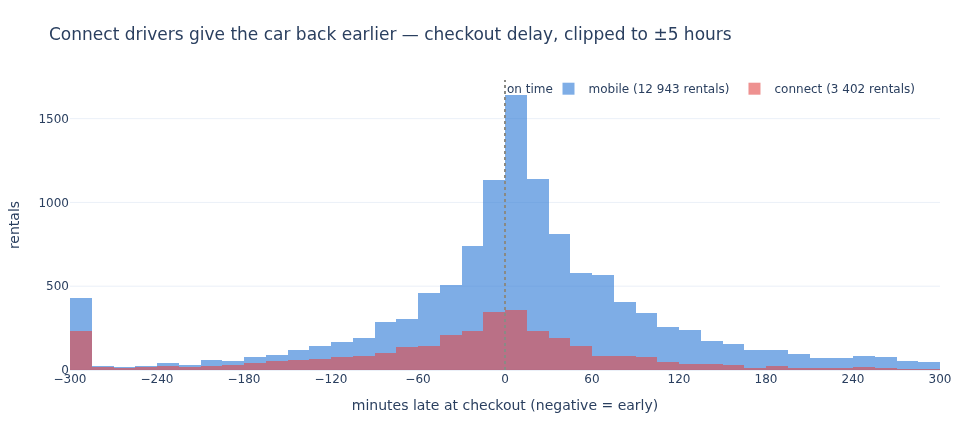

              rentals  late %  median    q90  over 1 h %
checkin_type                                            
connect          3402   0.429    -9.0   98.9       0.163
mobile          12943   0.614    14.0  231.0       0.296


In [4]:
fig = go.Figure()
for kind, color in [('mobile', BLUE), ('connect', RED)]:
    s = ended[ended['checkin_type'] == kind]['delay_at_checkout_in_minutes'].dropna()
    fig.add_trace(go.Histogram(x=s.clip(-300, 300), name=f'{kind} ({len(s):,} rentals)'.replace(',', ' '),
                               marker_color=color, opacity=0.6, xbins=dict(start=-300, end=300, size=15)))
fig.add_vline(x=0, line_dash='dot', line_color=GREY,
              annotation_text='on time', annotation_position='top right')
fig.update_layout(
    barmode='overlay',
    title='Connect drivers give the car back earlier — checkout delay, clipped to ±5 hours',
    xaxis=dict(title='minutes late at checkout (negative = early)', dtick=60),
    yaxis=dict(title='rentals'),
    legend=dict(orientation='h', y=1.02, x=0.55),
)
show(fig, '1_delay_distribution', height=430)

print(ended.dropna(subset=['delay_at_checkout_in_minutes'])
      .groupby('checkin_type')['delay_at_checkout_in_minutes']
      .agg(rentals='size', **{'late %': lambda s: (s > 0).mean(), 'median': 'median',
                              'q90': lambda s: s.quantile(0.9),
                              'over 1 h %': lambda s: (s > 60).mean()}).round(3).to_string())

**Connect drivers are the better-behaved half, not the worse one.** 42.9% of them are late against
61.4% on mobile, their median checkout is **9 minutes early** against 14 minutes late, and their
90th percentile is 99 minutes against 231. Section 4.2 is where this becomes the answer to the
scope question.

### 2.2 The 1 700 ended rentals with no checkout time

In [5]:
miss = ended['delay_at_checkout_in_minutes'].isna()
print(f'ended rentals with no checkout recorded: {miss.sum():,} ({miss.mean():.1%})'.replace(',', ' '))
print('\nrate by check-in type:')
print(ended.assign(m=miss).groupby('checkin_type')['m'].agg(rentals='size', missing='sum',
                                                            rate='mean').round(4).to_string())
chained_ids = delay['previous_ended_rental_id'].dropna()
print(f'\nof those, the previous rental of a chained one: '
      f'{ended.loc[miss, "rental_id"].isin(chained_ids).sum()} rentals')
print(f'a rental can precede more than one: {len(chained_ids)} links from '
      f'{chained_ids.nunique()} distinct rentals')

ended rentals with no checkout recorded: 1 700 (9.4%)

rate by check-in type:
              rentals  missing    rate
checkin_type                          
connect          3509      107  0.0305
mobile          14536     1593  0.1096

of those, the previous rental of a chained one: 108 rentals
a rental can precede more than one: 1841 links from 1788 distinct rentals


Nine per cent of ended rentals have no checkout timestamp, and the rate is **11.0% on mobile
against 3.1% on Connect** — the paper-and-smartphone flow is the one that gets skipped. These rows
are not dropped either: they are still rentals, they still count in every denominator, and **108 of
them are the *previous* rental of a chained one**, which is the only place they cost anything.

That 108 becomes 112 pairs in section 3.2, and the gap is a property of the file worth knowing:
**1 841 links come from only 1 788 distinct rentals**, because a single rental can be recorded as
the predecessor of two, three, even four others — the booking after it was made and cancelled more
than once. The blind spot is carried as 112 pairs rather than deleted.

## 3. How often are drivers late, and does it reach the next driver?

### 3.1 The feature can only touch the rentals that follow another one

In [6]:
linked = delay[delay['previous_ended_rental_id'].notna()]
pairs = linked.merge(delay.add_prefix('prev_'), left_on='previous_ended_rental_id',
                     right_on='prev_rental_id', how='left')
print(f'previous rental resolved inside the file: {pairs["prev_rental_id"].notna().sum()} / {len(pairs)}')
print(f'state of the previous rental            : {dict(pairs["prev_state"].value_counts())}')
print()
print(f'all rentals                     : {len(delay):>6,}   100.0%'.replace(',', ' '))
print(f'chained (have a previous rental): {len(linked):>6,}   {len(linked) / len(delay):>5.1%}'.replace(',', ' '))
print()
print('chained rate by check-in type:')
print(delay.assign(chained=delay['previous_ended_rental_id'].notna())
      .groupby('checkin_type')['chained'].agg(rentals='size', chained='sum', rate='mean')
      .round(4).to_string())
print()
print('the gap to the previous rental, in minutes:')
print(linked['time_delta_with_previous_rental_in_minutes'].describe().round(1)
      .rename(lambda i: f'  {i}').to_string())

previous rental resolved inside the file: 1841 / 1841
state of the previous rental            : {'ended': np.int64(1841)}

all rentals                     : 21 310   100.0%
chained (have a previous rental):  1 841    8.6%

chained rate by check-in type:
              rentals  chained    rate
checkin_type                          
connect          4307      813  0.1888
mobile          17003     1028  0.0605

the gap to the previous rental, in minutes:
count    1841.0
mean      279.3
std       254.6
min         0.0
25%        60.0
50%       180.0
75%       540.0
max       720.0


**Only 1 841 of the 21 310 rentals — 8.6% — follow another rental of the same car**, and the
feature cannot affect any of the other 19 469. Every previous rental resolves inside the file and
every one of them ended, so the chain is complete.

Two properties of that column decide the shape of everything below. The gap **never exceeds 720
minutes**: the file records a link only when two rentals are less than 12 hours apart, so a
threshold beyond 12 hours cannot be evaluated here and is not simulated. And **Connect cars are
chained three times more often than mobile ones** — 18.9% against 6.1%. That single number is why
the problem looks like a Connect problem.

### 3.2 An overlap is a delay bigger than the gap

In [7]:
p = pairs[pairs['prev_delay_at_checkout_in_minutes'].notna()].copy()
p['overlap'] = (p['prev_delay_at_checkout_in_minutes']
                - p['time_delta_with_previous_rental_in_minutes'])

print(f'chained pairs                          : {len(pairs):>5}')
print(f'  with the previous checkout recorded  : {len(p):>5}  <- everything below')
print(f'  blind spot (no previous checkout)    : {len(pairs) - len(p):>5}')
print()
print(f'previous driver late at all (> 0 min)  : {(p["prev_delay_at_checkout_in_minutes"] > 0).sum():>5}'
      f'  ({(p["prev_delay_at_checkout_in_minutes"] > 0).mean():.1%} of the pairs)')
print(f'OVERLAP: came back after the next check-in was due')
print(f'                                       : {(p["overlap"] > 0).sum():>5}'
      f'  ({(p["overlap"] > 0).mean():.1%} of the pairs, '
      f'{(p["overlap"] > 0).sum() / len(delay):.1%} of all rentals)')
print(f'  of which more than 1 h of overlap    : {(p["overlap"] > 60).sum():>5}')

chained pairs                          :  1841
  with the previous checkout recorded  :  1729  <- everything below
  blind spot (no previous checkout)    :   112

previous driver late at all (> 0 min)  :   873  (50.5% of the pairs)
OVERLAP: came back after the next check-in was due
                                       :   218  (12.6% of the pairs, 1.0% of all rentals)
  of which more than 1 h of overlap    :    66


Half the previous drivers are late by *something*, and it usually does not matter: **218 of the
1 729 measurable pairs — 12.6% — actually overlap** the next check-in, and only **66 overlap by
more than an hour**. In the whole file of 21 310 rentals, that is **1.0% and 0.3%**.

The 112 pairs whose previous rental has no recorded checkout are the blind spot. If they behaved
like the rest, they would add about 14 overlaps; they are left out rather than imputed, and every
count below is therefore a slight under-estimate.

### 3.3 Does an overlap actually hurt the next driver?

In [8]:
BANDS = [-10 ** 9, 0, 30, 60, 120, 10 ** 9]
NAMES = ['no overlap', '0-30 min', '30-60 min', '1-2 h', 'more than 2 h']
p['band'] = pd.cut(p['overlap'], BANDS, labels=NAMES)
impact = (p.groupby('band', observed=True)
          .agg(pairs=('state', 'size'), canceled=('state', lambda s: (s == 'canceled').sum()),
               rate=('state', lambda s: (s == 'canceled').mean())))
print('cancellation rate of the NEXT rental, by how much the previous one overlapped it')
print(impact.round(4).to_string())
print(f'\nbaseline: cancellation rate over all {len(delay):,} rentals = '
      f'{(delay["state"] == "canceled").mean():.1%}'.replace(',', ' '))

cancellation rate of the NEXT rental, by how much the previous one overlapped it
               pairs  canceled    rate
band                                  
no overlap      1511       169  0.1118
0-30 min         115        10  0.0870
30-60 min         37         8  0.2162
1-2 h             25         3  0.1200
more than 2 h     41        16  0.3902

baseline: cancellation rate over all 21 310 rentals = 15.3%


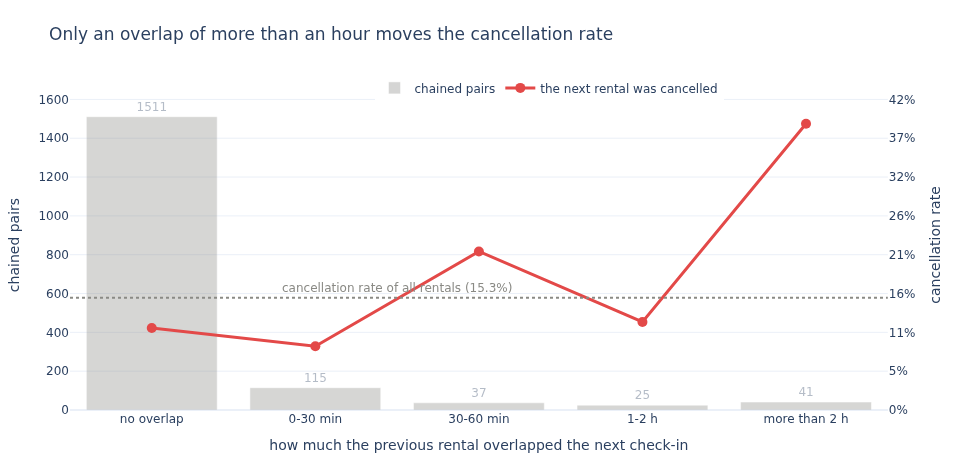

In [9]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=NAMES, y=impact['pairs'], name='chained pairs',
                     marker_color=GREY, opacity=0.35,
                     text=impact['pairs'], textposition='outside'))
fig.add_trace(go.Scatter(x=NAMES, y=impact['rate'], name='the next rental was cancelled',
                         mode='lines+markers', line=dict(color=RED, width=3),
                         marker=dict(size=10)), secondary_y=True)
baseline = (delay['state'] == 'canceled').mean()
fig.add_hline(y=baseline, line_dash='dot', line_color=GREY, secondary_y=True)
fig.add_annotation(x=1.5, y=baseline, yref='y2', yshift=10, showarrow=False, font=dict(color=GREY),
                   text=f'cancellation rate of all rentals ({baseline:.1%})')
fig.update_layout(
    title='Only an overlap of more than an hour moves the cancellation rate',
    xaxis=dict(title='how much the previous rental overlapped the next check-in'),
    legend=dict(orientation='h', y=1.02, x=0.35),
)
# Both axes are pinned from zero: the bars carry the sample size behind each rate, and a
# truncated axis would make 41 pairs look like a solid measurement.
fig.update_yaxes(title='chained pairs', range=[0, 1700], secondary_y=False)
fig.update_yaxes(title='cancellation rate', tickformat='.0%', range=[0, 0.45],
                 showgrid=False, secondary_y=True)
show(fig, '2_overlap_impact', height=470)

**An overlap under half an hour has no measurable effect**: 8.7% of those next rentals were
cancelled, *below* the 15.3% baseline, on 115 pairs. The rate only moves past an hour of overlap —
**39.0% beyond two hours, on 41 pairs.**

Two warnings that belong on the same line as that number. The bars are the sample size, and the
whole right-hand half of the chart rests on **103 pairs**. And a cancellation recorded after a late
checkout is not proof the late checkout caused it: the file has no cancellation reason, and a
driver who cancels may never have known the car was late.

What survives both warnings is enough to steer the decision: **the cases worth preventing are the
66 pairs with more than an hour of overlap**, and there are 66 of them.

## 4. Threshold and scope: what each choice buys, and what it costs

The feature refuses a booking when the gap to the previous checkout is shorter than the threshold.
So a threshold of *T* minutes **blocks** every chained rental whose gap is under *T* — that is the
cost — and **prevents** exactly those overlaps that happened inside a gap under *T*. An overlap
inside a wider gap is untouched: no threshold catches a driver who is four hours late on a
six-hour gap.

In [10]:
def simulate(threshold, scope='all', severity=0):
    """Rentals blocked and overlaps prevented, at one threshold and one scope.

    severity=0 counts every overlap, severity=60 only those worth more than an hour.
    """
    sub = p if scope == 'all' else p[p['checkin_type'] == scope]
    under = sub['time_delta_with_previous_rental_in_minutes'] < threshold
    return {'threshold': threshold, 'scope': scope,
            'blocked': int(under.sum()),
            'share of all rentals': under.sum() / len(delay),
            'overlaps prevented': int(((sub['overlap'] > 0) & under).sum()),
            'severe prevented': int(((sub['overlap'] > severity) & under).sum())}


GRID = [30, 60, 90, 120, 180, 240, 360, 480, 720]
sim = pd.DataFrame([simulate(t, s, severity=60) for s in ('all', 'connect') for t in GRID])
sim['blocked per severe case'] = sim['blocked'] / sim['severe prevented'].clip(lower=1)
print(f'severe cases (overlap > 1 h): {(p["overlap"] > 60).sum()} in total, '
      f'{((p["overlap"] > 60) & (p["checkin_type"] == "connect")).sum()} of them on Connect cars')
print()
print(sim.to_string(index=False, formatters={'share of all rentals': '{:.2%}'.format,
                                             'blocked per severe case': '{:.1f}'.format}))

severe cases (overlap > 1 h): 66 in total, 20 of them on Connect cars

 threshold   scope  blocked share of all rentals  overlaps prevented  severe prevented blocked per severe case
        30     all      261                1.22%                 116                28                     9.3
        60     all      381                1.79%                 146                36                    10.6
        90     all      550                2.58%                 172                45                    12.2
       120     all      630                2.96%                 180                48                    13.1
       180     all      828                3.89%                 196                54                    15.3
       240     all      951                4.46%                 202                57                    16.7
       360     all     1112                5.22%                 208                60                    18.5
       480     all     1222              

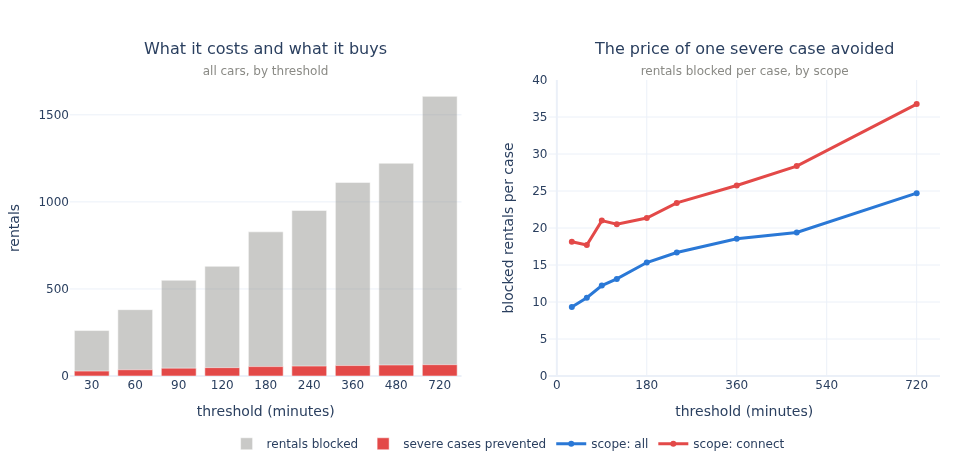

In [11]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.10,
                    subplot_titles=['What it costs and what it buys<br>'
                                    '<span style="font-size:12px;color:#8a8a85">'
                                    'all cars, by threshold</span>',
                                    'The price of one severe case avoided<br>'
                                    '<span style="font-size:12px;color:#8a8a85">'
                                    'rentals blocked per case, by scope</span>'])
a = sim[sim['scope'] == 'all']
fig.add_trace(go.Bar(x=a['threshold'], y=a['blocked'], name='rentals blocked',
                     marker_color=GREY, opacity=0.45), row=1, col=1)
fig.add_trace(go.Bar(x=a['threshold'], y=a['severe prevented'], name='severe cases prevented',
                     marker_color=RED), row=1, col=1)
for scope, color in [('all', BLUE), ('connect', RED)]:
    s = sim[sim['scope'] == scope]
    fig.add_trace(go.Scatter(x=s['threshold'], y=s['blocked per severe case'], mode='lines+markers',
                             name=f'scope: {scope}', line=dict(color=color, width=3)), row=1, col=2)
fig.update_layout(title=None, barmode='overlay',
                  legend=dict(orientation='h', y=-0.18, x=0.18))
fig.update_xaxes(title='threshold (minutes)', type='category', row=1, col=1)
fig.update_xaxes(title='threshold (minutes)', dtick=180, row=1, col=2)
fig.update_yaxes(title='rentals', range=[0, 1700], row=1, col=1)
fig.update_yaxes(title='blocked rentals per case', range=[0, 40], row=1, col=2)
show(fig, '3_threshold_and_scope', height=470)

### 4.1 The threshold: the trade never gets better, it only gets more expensive

Read the left panel from the bottom. The red bars are what the feature achieves — **36 severe cases
prevented at 60 minutes, 54 at three hours, 65 at twelve** — and the grey bars are what it costs:
**381 blocked rentals, then 828, then 1 606.**

The right-hand panel is the same two numbers as one ratio, and it rises monotonically. **There is
no threshold at which this trade is efficient.** At 60 minutes one severe case is bought for 10.6
blocked rentals; at three hours for 15.3; at twelve hours for 24.7. The question is not where the
optimum is — there is none — but how much the company is willing to pay per avoided incident. The
cheapest useful setting is the smallest one.

### 4.2 The scope: "Connect only" is the expensive half

In [12]:
print('problem rate among chained pairs, by check-in type')
print(p.assign(severe=p['overlap'] > 60)
      .groupby('checkin_type').agg(pairs=('overlap', 'size'),
                                   overlaps=('overlap', lambda s: (s > 0).sum()),
                                   severe=('severe', 'sum'),
                                   severe_rate=('severe', 'mean')).round(4).to_string())
print()
print('the three numbers that decide the scope, at a 60-minute threshold')
for scope in ('all', 'connect'):
    r = simulate(60, scope, severity=60)
    print(f"  {scope:>7}: {r['blocked']:>4} blocked ({r['share of all rentals']:.2%} of all rentals), "
          f"{r['severe prevented']:>3} severe cases prevented, "
          f"{r['blocked'] / max(r['severe prevented'], 1):.1f} blocked per case")

problem rate among chained pairs, by check-in type
              pairs  overlaps  severe  severe_rate
checkin_type                                      
connect         791        69      20       0.0253
mobile          938       149      46       0.0490

the three numbers that decide the scope, at a 60-minute threshold
      all:  381 blocked (1.79% of all rentals),  36 severe cases prevented, 10.6 blocked per case
  connect:  177 blocked (0.83% of all rentals),  10 severe cases prevented, 17.7 blocked per case


The scope question has a clean answer and it is not the intuitive one.

**Connect concentrates the chaining, not the lateness.** 18.9% of Connect rentals follow another
one against 6.1% on mobile, which is why the product manager sees the problem there. But among
chained pairs, the severe-overlap rate is **2.5% on Connect against 4.9% on mobile** — half. The
Connect flow is the one where the driver opens the car with a phone and nobody has to wait for a
handover, and it shows.

The consequence is arithmetic. At a 60-minute threshold, restricting the feature to Connect cars
blocks 177 rentals to prevent 10 severe cases — **17.7 blocked rentals per case, against 10.6 for
all cars.** Narrowing the scope to Connect makes the feature *less* efficient, not more, because it
aims it at the half of the fleet whose drivers are already on time.

## 5. What the product manager should decide

### 5.1 The recommendation

In [13]:
rec = simulate(60, 'all', severity=60)
print('RECOMMENDED SETTING: 60 minutes, all cars')
print(f"  rentals blocked            : {rec['blocked']} = {rec['share of all rentals']:.2%} of all rentals, "
      f"{rec['blocked'] / len(linked):.1%} of chained ones")
print(f"  severe cases prevented     : {rec['severe prevented']} of {(p['overlap'] > 60).sum()} "
      f"({rec['severe prevented'] / (p['overlap'] > 60).sum():.0%})")
print(f"  all overlaps prevented     : {rec['overlaps prevented']} of {(p['overlap'] > 0).sum()}")
print(f"  price                      : {rec['blocked'] / rec['severe prevented']:.1f} blocked rentals per case")
print()
print('what the alternatives cost, for comparison:')
for t, s in [(30, 'all'), (120, 'all'), (360, 'all'), (60, 'connect')]:
    r = simulate(t, s, severity=60)
    print(f"  {t:>3} min / {s:<7}: {r['blocked']:>4} blocked, {r['severe prevented']:>2} prevented, "
          f"{r['blocked'] / max(r['severe prevented'], 1):>4.1f} per case")

RECOMMENDED SETTING: 60 minutes, all cars
  rentals blocked            : 381 = 1.79% of all rentals, 20.7% of chained ones
  severe cases prevented     : 36 of 66 (55%)
  all overlaps prevented     : 146 of 218
  price                      : 10.6 blocked rentals per case

what the alternatives cost, for comparison:
   30 min / all    :  261 blocked, 28 prevented,  9.3 per case
  120 min / all    :  630 blocked, 48 prevented, 13.1 per case
  360 min / all    : 1112 blocked, 60 prevented, 18.5 per case
   60 min / connect:  177 blocked, 10 prevented, 17.7 per case


**Sixty minutes, all cars.** It is the cheapest setting that does anything: it removes **1.79% of
all rentals** from search results and prevents **36 of the 66 severe cases, 55%**. Every longer
threshold buys the remaining cases at a worse and worse rate, and every narrower scope aims the
feature at the drivers who are already punctual.

Thirty minutes is defensible too — 261 blocked for 28 prevented, the best ratio on the grid — and
the choice between the two is a judgement about how much a waiting driver is worth, which is not in
this file.

### 5.2 What this analysis cannot tell you, and what to log next

In [14]:
print('1. REVENUE. The pricing file has no car id, so no rental has a price.')
connect_price = pricing.loc[pricing['has_getaround_connect'], 'rental_price_per_day'].mean()
plain_price = pricing.loc[~pricing['has_getaround_connect'], 'rental_price_per_day'].mean()
print(f'   The best available proxy: a Connect car rents for {connect_price:.2f} EUR/day '
      f'against {plain_price:.2f} for a car without it.')
print(f'   -> a Connect rental is worth {connect_price / plain_price - 1:.0%} more than a plain one, '
      f'which makes the Connect-only scope worse still.')
print()
print('2. A BLOCKED RENTAL IS NOT A LOST RENTAL. The file cannot say whether the driver')
print('   rebooked the same car later or another car; 1.79% is an upper bound on the loss.')
print()
print('3. DURATION IS NOT IN THE FILE. Revenue is a price times a number of days, and')
print(f'   neither is recorded:', f'{len(delay):,} rentals'.replace(',', ' '),
      '/ no start date / no end date.')
print()
print(f'4. THE 12-HOUR CAP. {linked["time_delta_with_previous_rental_in_minutes"].max():.0f} minutes is the '
      f'largest gap in the file, so a threshold above 12 h cannot be evaluated.')

1. REVENUE. The pricing file has no car id, so no rental has a price.
   The best available proxy: a Connect car rents for 132.79 EUR/day against 111.34 for a car without it.
   -> a Connect rental is worth 19% more than a plain one, which makes the Connect-only scope worse still.

2. A BLOCKED RENTAL IS NOT A LOST RENTAL. The file cannot say whether the driver
   rebooked the same car later or another car; 1.79% is an upper bound on the loss.

3. DURATION IS NOT IN THE FILE. Revenue is a price times a number of days, and
   neither is recorded: 21 310 rentals / no start date / no end date.

4. THE 12-HOUR CAP. 720 minutes is the largest gap in the file, so a threshold above 12 h cannot be evaluated.


Four limits, in the order they would change a decision:

1. **No revenue figure is possible from these files.** Every "share of revenue" in this notebook is
   a share of *rentals*, which assumes every rental is worth the same. The one real signal is that
   Connect cars rent for **€132.79 a day against €111.34** — 19% more — so the Connect-only scope
   is even more expensive per case than the rental counts say.
2. **A blocked rental is not a lost rental.** 1.79% is the upper bound of the cost, not the cost.
3. **Duration is missing**, so a two-hour rental and a five-day rental count the same.
4. **The file caps the gap at 12 hours**, so nothing beyond that is measurable here.

The fix for the first three is one join and two columns: put `car_id` in the pricing export, and
log the rental's start and end. Then this whole analysis re-runs in euros instead of counts.

## 6. The pricing model behind `/predict`

The second half of the brief is the pricing recommendation the API serves: given a car, suggest a
daily price. 4 843 cars, thirteen features, one target.

### 6.1 Three impossible values, and what removing them costs

In [15]:
impossible = ((pricing['mileage'] < 0) | (pricing['mileage'] > 500_000)
              | (pricing['engine_power'] == 0))
print(f'mileage below zero        : {(pricing["mileage"] < 0).sum()} '
      f'-> {list(pricing.loc[pricing["mileage"] < 0, "mileage"])}')
print(f'mileage above 500 000 km  : {(pricing["mileage"] > 500_000).sum()} '
      f'-> {list(pricing.loc[pricing["mileage"] > 500_000, "mileage"])}')
print(f'engine power of zero      : {(pricing["engine_power"] == 0).sum()}')
print(f'\nrows flagged: {impossible.sum()} of {len(pricing):,} = {impossible.mean():.2%}'.replace(',', ' '))
print(f'\nprice below 25 EUR/day    : {(pricing["rental_price_per_day"] < 25).sum()} cars '
      f'-> {sorted(pricing.loc[pricing["rental_price_per_day"] < 25, "rental_price_per_day"].unique())}')

mileage below zero        : 1 -> [-64]
mileage above 500 000 km  : 1 -> [1000376]
engine power of zero      : 1

rows flagged: 3 of 4 843 = 0.06%

price below 25 EUR/day    : 18 cars -> [np.int64(10), np.int64(14), np.int64(20), np.int64(22), np.int64(24)]


Three rows are physically impossible — a car cannot have run −64 km, nor 1 000 376, nor have a
zero-power engine — and they go. That is **0.06% of the file**, too small to change a score;
they are removed because serving a prediction fitted on a negative mileage is indefensible, not
because it helps.

The eighteen cars priced under €25 a day stay. Ten euros is a strange price but it is not an
impossible one, and this is a model of what owners *do* charge.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

clean = pricing[~impossible].reset_index(drop=True)
NUMERIC = ['mileage', 'engine_power']
CATEGORICAL = ['model_key', 'fuel', 'paint_color', 'car_type']
BOOLEAN = ['private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car',
           'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
FEATURES = NUMERIC + CATEGORICAL + BOOLEAN
TARGET = 'rental_price_per_day'

X, y = clean[FEATURES], clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# handle_unknown matters here for a reason that is not statistical: the endpoint is public and
# will be sent model_key values that were never in the training set. Unknown levels have to be
# encoded, not raise.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                          sparse_output=False), CATEGORICAL),
    ('bool', 'passthrough', BOOLEAN),
])
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f'train {len(X_train):,} cars | test {len(X_test):,} cars'.replace(',', ' '),
      f'| price {y.min()}-{y.max()} EUR, median {y.median():.0f} EUR')

train 3 872 cars | test 968 cars | price 10-422 EUR, median 119 EUR


### 6.2 Four models, and what each is worth

In [17]:
CANDIDATES = {
    'the median price of every car': DummyRegressor(strategy='median'),
    'linear regression': LinearRegression(),
    'ridge (alpha chosen by CV)': RidgeCV(alphas=np.logspace(-2, 3, 30)),
    'random forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'gradient boosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows = []
for name, estimator in CANDIDATES.items():
    pipe = Pipeline([('pre', preprocessor), ('model', estimator)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    row = {'model': name, 'CV R2': scores.mean(), 'CV std': scores.std(),
           'test R2': r2_score(y_test, pred), 'test MAE': mean_absolute_error(y_test, pred),
           'median error': np.median(np.abs(y_test - pred))}
    rows.append(row)

leaderboard = pd.DataFrame(rows)
print(leaderboard.to_string(index=False, float_format='{:.3f}'.format))

                        model  CV R2  CV std  test R2  test MAE  median error
the median price of every car -0.009   0.009   -0.002    24.131        16.000
            linear regression  0.697   0.038    0.713    12.409         8.860
   ridge (alpha chosen by CV)  0.697   0.039    0.712    12.415         8.856
                random forest  0.748   0.041    0.747    10.877         6.847
            gradient boosting  0.755   0.040    0.756    10.933         7.217


Charging every car the median €119 is wrong by **€24.13 on average**. The linear model nearly
halves that to €12.41, and the two ensembles take another €1.50 off it — after which the four
non-trivial models sit inside a range of 0.06 R².

Gradient boosting wins on both the cross-validated and the held-out R², so it is the one that gets
tuned. It is worth saying that the random forest is €0.06 better on MAE, which is not a difference:
the cross-validated standard deviation is 0.04 of R², six times the gap between the two.

In [18]:
search = GridSearchCV(
    Pipeline([('pre', preprocessor), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [200, 400],
     'model__max_leaf_nodes': [15, 31, 63], 'model__min_samples_leaf': [10, 20, 40]},
    cv=cv, scoring='r2', n_jobs=-1)
search.fit(X_train, y_train)
best = search.best_estimator_
pred = best.predict(X_test)

print('best parameters:', {k.replace('model__', ''): v for k, v in search.best_params_.items()})
print(f'CV R2        : {search.best_score_:.4f}')
print(f'test R2      : {r2_score(y_test, pred):.4f}')
print(f'test MAE     : {mean_absolute_error(y_test, pred):.2f} EUR')
print(f'median error : {np.median(np.abs(y_test - pred)):.2f} EUR on a median price of {y_test.median():.0f} EUR')

best parameters: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 10}
CV R2        : 0.7624
test R2      : 0.7705
test MAE     : 10.59 EUR
median error : 7.12 EUR on a median price of 120 EUR


**€10.59 of average error on a median price of €120**, and half the cars are priced within
**€7.12**. Tuning bought 0.007 of cross-validated R² over the default gradient boosting — the grid
of 36 combinations is in the cell, and it is worth reporting that it changed almost nothing.

### 6.3 The price is the car, not the equipment

In [19]:
GROUPS = {
    'everything (13 features)': (NUMERIC, CATEGORICAL, BOOLEAN),
    'the car only — engine, mileage, model, fuel, type': (NUMERIC, ['model_key', 'fuel', 'car_type'], []),
    'the options only — 7 booleans and the colour': ([], ['paint_color'], BOOLEAN),
    'engine_power alone': (['engine_power'], [], []),
}
for label, (num, cat, boo) in GROUPS.items():
    steps = ([('num', StandardScaler(), num)] if num else [])
    steps += ([('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                                     sparse_output=False), cat)] if cat else [])
    steps += ([('bool', 'passthrough', boo)] if boo else [])
    pipe = Pipeline([('pre', ColumnTransformer(steps)),
                     ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    print(f'{label:<52} CV R2 {s.mean():.3f} +/-{s.std():.3f}')

everything (13 features)                             CV R2 0.755 +/-0.040


the car only — engine, mileage, model, fuel, type    CV R2 0.717 +/-0.040


the options only — 7 booleans and the colour         CV R2 0.344 +/-0.025


engine_power alone                                   CV R2 0.460 +/-0.028


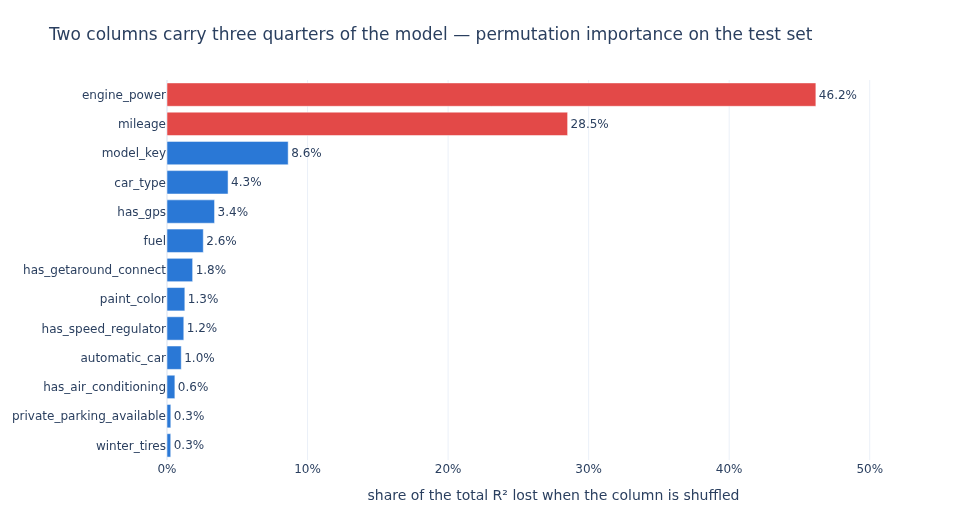

engine_power                 46.2
mileage                      28.5
model_key                     8.6
car_type                      4.3
has_gps                       3.4
fuel                          2.6
has_getaround_connect         1.8
paint_color                   1.3
has_speed_regulator           1.2
automatic_car                 1.0
has_air_conditioning          0.6
private_parking_available     0.3
winter_tires                  0.3


In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='r2')
importance = (pd.Series(perm.importances_mean, index=FEATURES)
              .sort_values() / perm.importances_mean.sum())
fig = go.Figure(go.Bar(
    x=importance.values, y=importance.index, orientation='h',
    marker_color=[RED if f in NUMERIC else BLUE for f in importance.index],
    text=[f'{v:.1%}' for v in importance.values], textposition='outside',
))
fig.update_layout(
    title='Two columns carry three quarters of the model — permutation importance on the test set',
    xaxis=dict(title='share of the total R² lost when the column is shuffled', tickformat='.0%',
               range=[0, 0.55]),
    yaxis=dict(title=None), showlegend=False,
)
show(fig, '4_feature_importance', height=520)
print(importance.sort_values(ascending=False).mul(100).round(1)
      .rename('% of the total drop').to_string())

**The two columns an owner cannot change carry 75% of the model.** `engine_power` alone is 46.2% of
it and `mileage` 28.5%; the seven equipment booleans and the paint colour together are 9.9%.

Fitted on the car's own characteristics only, the model reaches **CV R² 0.717**. Adding everything
the owner controls — GPS, air conditioning, automatic gearbox, Connect, speed regulator, winter
tyres, private parking, colour — takes it to **0.755**, under four points. Those same options
fitted *alone* reach 0.344.

This is the honest description of what `/predict` does: it tells an owner **what their car is
worth**, not what to do about it. That is still the useful answer for the recommendation the brief
asks for — an owner setting a price wants the market rate for their car — but it should not be
sold as an optimiser, because there is very little in it to optimise.

In [21]:
final = Pipeline([('pre', preprocessor),
                  ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                                          **{k.replace('model__', ''): v
                                                             for k, v in search.best_params_.items()}))])
final.fit(X, y)   # the deployed model is refitted on all 4 840 cars, train and test

sample = X.head(2).values.tolist()
print('the pipeline training/train.py fits, refitted on all',
      f'{len(X):,} cars'.replace(',', ' '))
print(f'  steps        : {[name for name, _ in final.steps]}')
print(f'  feature order: {FEATURES}')
print(f'\nthe endpoint contract, checked here so the API cannot disagree with the notebook:')
print(f'  input      : {json.dumps({"input": sample})[:108]}...')
print(f'  prediction : {[round(float(v), 2) for v in final.predict(X.head(2))]} EUR/day')

the pipeline training/train.py fits, refitted on all 4 840 cars
  steps        : ['pre', 'model']
  feature order: ['mileage', 'engine_power', 'model_key', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

the endpoint contract, checked here so the API cannot disagree with the notebook:
  input      : {"input": [[140411, 100, "Citro\u00ebn", "diesel", "black", "convertible", true, true, false, false, true, t...
  prediction : [107.91, 264.38] EUR/day


This notebook stops here, one step short of an artefact. **The model that ships is fitted and
registered by [`training/train.py`](training/train.py)**, which logs this exact pipeline to the
shared MLflow registry, records the same held-out metrics against it, and moves the `champion`
alias to the new version. The API resolves `models:/getaround-pricing-model@champion` at startup,
so promoting a better model is an alias move rather than a redeployment.

Two properties of that split are worth stating. What gets logged is **the whole pipeline** —
scaler, encoder and regressor — so the API owns no feature engineering and only ever calls
`.predict(...)`; the column order and the column types it enforces come from the logged signature
rather than from a list written twice. And the registered model is **refitted on all 4 840 cars**,
train and test together: the split existed to choose the model, and once chosen there is no reason
to serve a version trained on 80% of the data.

The two prices printed above are the check that keeps the notebook and the endpoint honest: the
deployed `/predict` returns the same two numbers for the same two cars.

## 7. What ships

**1. Set the buffer to 60 minutes, on all cars.** It costs 1.79% of rentals and prevents 55% of the
cases where the cancellation rate actually moves. Every longer threshold pays more per case, and
every longer threshold is a decision about price, not about evidence.

**2. Do not restrict the scope to Connect.** Connect concentrates the *chaining*, not the
*lateness* — its drivers are late 43% of the time against 61%, and its chained pairs go badly wrong
half as often. Connect-only costs 17.7 blocked rentals per severe case against 10.6.

**3. Expect the feature to be small.** Its entire target is 66 rentals in 21 310. It is worth
shipping because a driver standing in the street is a bad experience, not because the numbers are
large — and it should be sized, staffed and monitored as the small feature it is.

**4. Log three columns and this becomes a revenue analysis.** `car_id` in the pricing export, and
the rental's start and end. Today every cost in this notebook is a count of rentals standing in for
euros.

**5. `/predict` returns the market rate for a car, and should be presented that way.** €10.59 of
average error on a €120 median, and 75% of the model in two columns the owner cannot change. An
owner who wants a higher price needs a different car, not a different checkbox — the model is
honest about that, and the product copy should be too.

**6. The three pieces built from this notebook.** `training/train.py` fits the pipeline above and
registers it in the MLflow registry under the `champion` alias. The API in `api/` pulls it by that
alias at startup and serves it at `/predict`, documented at `/docs`. The dashboard in `dashboard/`
re-runs sections 3 to 5 interactively, so the product manager can move the threshold and the scope
themselves. Both services are deployed as Hugging Face Spaces, and the README carries the URLs.